## 1. Import Library

In [11]:
# General
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import joblib

# Imbalanced
from imblearn.over_sampling import SMOTE
from collections import Counter

## 2. Data Loading

In [2]:
df = pd.read_csv('/content/curn_cleaned_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Preprocessing

In [3]:
df_ml = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

X = df_ml.drop('Exited', axis=1)
y = df_ml['Exited']

X = pd.get_dummies(X, drop_first=True)

print("Shape X:", X.shape)
print("Distribusi target:")
print(y.value_counts(normalize=True).round(3))

Shape X: (10000, 11)
Distribusi target:
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


## 4. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 8000 rows | Test: 2000 rows


## 5. Handle Imbalanced Data (SMOTE)

Dataset ini imbalance, dimana churn hanya 20% sehingga digunakan SMOTE untuk menangani imbalanced data. SMOTE diterapkan pada data training aja.

In [5]:
print("Sebelum SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Setelah SMOTE:", Counter(y_train_res))

Sebelum SMOTE: Counter({0: 6370, 1: 1630})
Setelah SMOTE: Counter({1: 6370, 0: 6370})


## 6. Feature Scaling

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

## 7. Modelling

Dua model dibandingkan:
- **Logistic Regression** — baseline linear model, mudah diinterpretasi
- **Random Forest** — ensemble model, lebih kuat untuk data non-linear seperti perilaku nasabah

In [7]:
# Logistic Regression
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train_res)

# Random Forest (tidak perlu scaling)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

print("Training selesai.")

Training selesai.


## 8. Evaluasi Model

Metrik yang digunakan:
- **Recall** — seberapa banyak pelanggan churn yang berhasil terdeteksi
- **Precision** — dari yang diprediksi churn, berapa yang benar-benar churn
- **F1 Score** — keseimbangan antara precision dan recall
- **ROC-AUC** — kemampuan model membedakan kelas secara keseluruhan

In [8]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
    }

results = [
    evaluate_model('Logistic Regression', log_model, X_test_scaled, y_test),
    evaluate_model('Random Forest',       rf_model,  X_test,        y_test),
]

df_results = pd.DataFrame(results).set_index('Model')
df_results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7335,0.3939,0.5749,0.4675,0.7313
Random Forest,0.8160,0.5389,0.6634,0.5947,0.8478


## 9. Confusion Matrix

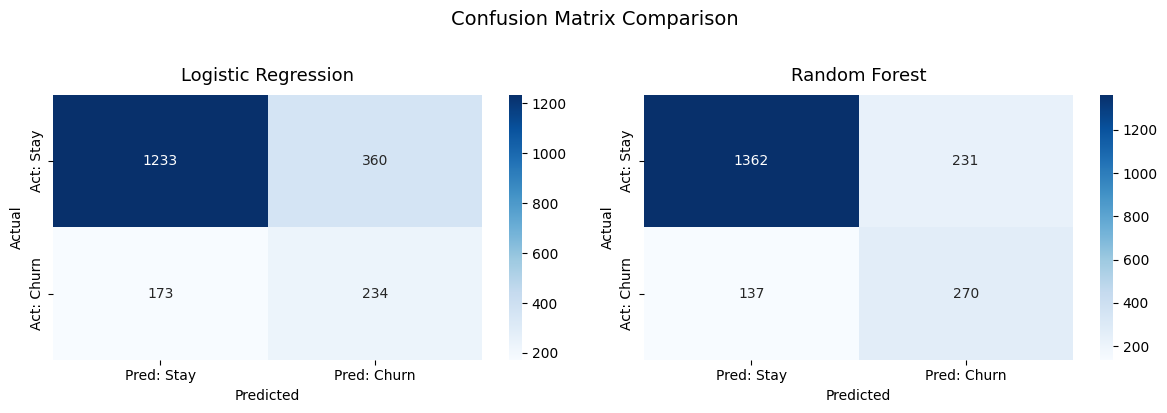

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models_plot = [
    ('Logistic Regression', log_model, X_test_scaled),
    ('Random Forest',       rf_model,  X_test),
]

for ax, (name, model, X_input) in zip(axes, models_plot):
    cm = confusion_matrix(y_test, model.predict(X_input))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Pred: Stay', 'Pred: Churn'],
        yticklabels=['Act: Stay',  'Act: Churn']
    )
    ax.set_title(name, fontsize=13, pad=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Feature Importance (Random Forest)

Fitur mana yang paling berpengaruh terhadap keputusan churn nasabah.

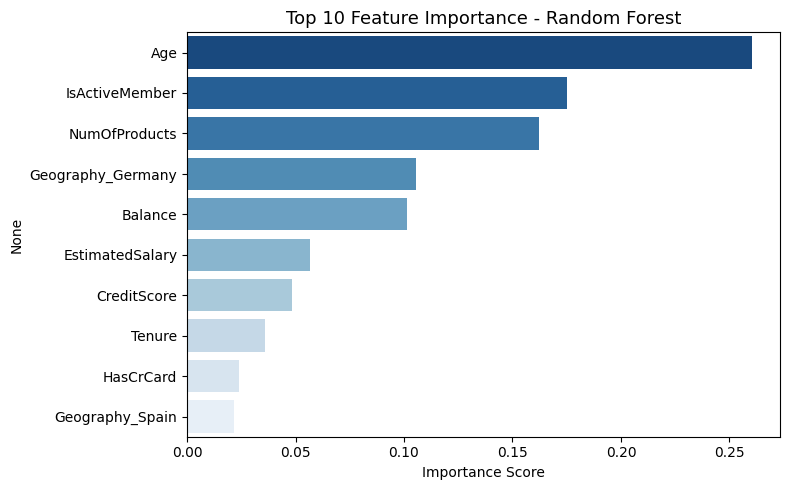

In [10]:
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
plt.title('Top 10 Feature Importance - Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 11. Kesimpulan

| | Logistic Regression | Random Forest |
|---|---|---|
| Kelebihan | Cepat, mudah diinterpretasi | Lebih akurat, tangkap pola non-linear |
| Kekurangan | Kurang akurat untuk data kompleks | Lebih lambat, kurang transparan |

**Model terpilih: Random Forest** — memberikan F1 Score dan ROC-AUC yang lebih tinggi, cocok untuk kebutuhan prediksi churn di industri perbankan.

## 12. Save model

In [12]:
joblib.dump(log_model, "longistic_regression_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
print("Model berhasil disimpan!")

Model berhasil disimpan!


## 13. Prediksi

In [20]:
# Isi data nasabah yang ingin diprediksi
new_customer = {
    'CreditScore'    : 620,
    'Age'            : 45,
    'Tenure'         : 3,
    'Balance'        : 120000.00,
    'NumOfProducts'  : 1,
    'HasCrCard'      : 1,
    'IsActiveMember' : 0,
    'EstimatedSalary': 85000.00,
    'Geography_Germany': 0,   # 1 jika Germany, 0 jika tidak
    'Geography_Spain'  : 0,   # 1 jika Spain, 0 jika tidak
    'Gender_Male'      : 0,   # 1 jika Male, 0 jika Female
}

input_df = pd.DataFrame([new_customer])[X.columns]

input_scaled = scaler.transform(input_df)

pred       = rf_model.predict(input_scaled)[0]
prob_churn = rf_model.predict_proba(input_scaled)[0][1]

print(f"  Hasil Prediksi Nasabah")
print(f"  Status  : {' CHURN' if pred == 1 else 'STAY'}")
print(f"  Churn Probability : {prob_churn:.1%}")

if prob_churn >= 0.6:
    print("  Risiko TINGGI — perlu tindakan segera")
elif prob_churn >= 0.3:
    print("  Risiko SEDANG — perlu dipantau")
else:
    print("  Risiko RENDAH — nasabah relatif aman")

  Hasil Prediksi Nasabah
  Status  : STAY
  Churn Probability : 32.0%
  Risiko SEDANG — perlu dipantau


In [19]:
# Upload file CSV
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_new = pd.read_csv(filename)
print(f"Data dimuat: {df_new.shape[0]} nasabah")
df_new.head()

Saving curn_cleaned_data.csv to curn_cleaned_data (1).csv
Data dimuat: 10000 nasabah


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [21]:
df_pred = df_new.copy()

drop_cols = [c for c in ['RowNumber', 'CustomerId', 'Surname'] if c in df_pred.columns]
df_pred = df_pred.drop(columns=drop_cols)

if 'Exited' in df_pred.columns:
    df_pred = df_pred.drop(columns=['Exited'])

df_pred = pd.get_dummies(df_pred, drop_first=True)

for col in X.columns:
    if col not in df_pred.columns:
        df_pred[col] = 0

df_pred = df_pred[X.columns]
df_pred_scaled = scaler.transform(df_pred)

pred_labels = rf_model.predict(df_pred_scaled)
pred_proba  = rf_model.predict_proba(df_pred_scaled)[:, 1]

df_result = df_new.copy()
df_result['Churn_Prediction'] = pred_labels
df_result['Churn_Probability'] = pred_proba.round(4)
df_result['Risk_Level'] = pd.cut(
    pred_proba,
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High']
)

print(f"Selesai. Total prediksi: {len(df_result)}")
print(df_result['Risk_Level'].value_counts())
df_result.head(10)

Selesai. Total prediksi: 10000
Risk_Level
Low       8552
Medium    1448
High         0
Name: count, dtype: int64


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Churn_Prediction,Churn_Probability,Risk_Level
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,0.2978,Low
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,0.4021,Medium
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,0.3706,Low
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0.2842,Low
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,0.3437,Low
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,0,0.3990,Low
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0,0.2374,Low
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,0,0.4415,Medium
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,0.3076,Low
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,0.2934,Low


In [22]:
# Simpan hasil prediksi ke CSV
output_filename = 'churn_predictions.csv'
df_result.to_csv(output_filename, index=False)

# Download otomatis
files.download(output_filename)
print(f"File '{output_filename}' berhasil didownload.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'churn_predictions.csv' berhasil didownload.


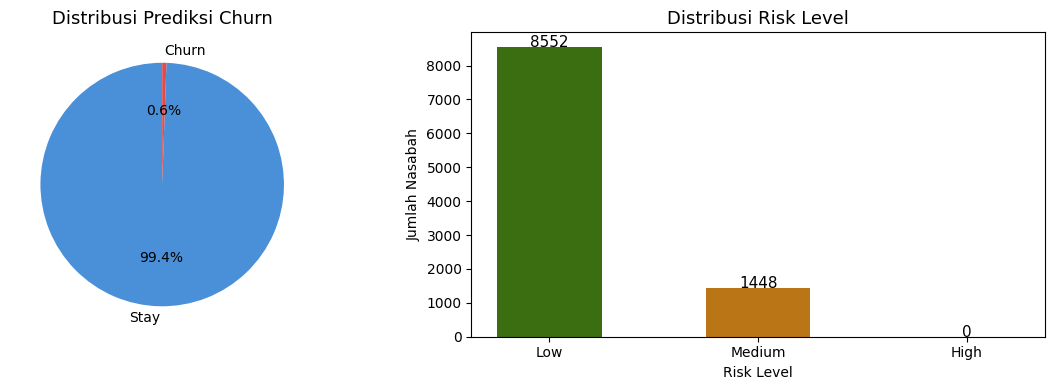

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart distribusi churn
churn_counts = df_result['Churn_Prediction'].value_counts()
axes[0].pie(
    churn_counts,
    labels=['Stay', 'Churn'],
    autopct='%1.1f%%',
    colors=['#4A90D9', '#E24B4A'],
    startangle=90
)
axes[0].set_title('Distribusi Prediksi Churn', fontsize=13)

# Bar chart risk level
risk_counts = df_result['Risk_Level'].value_counts().reindex(['Low', 'Medium', 'High'])
colors = ['#3B6D11', '#BA7517', '#A32D2D']
axes[1].bar(risk_counts.index, risk_counts.values, color=colors, width=0.5)
axes[1].set_title('Distribusi Risk Level', fontsize=13)
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Jumlah Nasabah')
for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()